# RFSoC-PYNQ Multi-Tile Sync Acquisition Design
---

This notebook is based on Xilinx [RFSoC-MTS](https://github.com/Xilinx/RFSoC-MTS/blob/main/boards/ZCU208/notebooks/rfsocMTS.ipynb).

This overlay provides one DAC player memory that is broadcast to multiple RF DAC tiles. DACs in use are Tiles 228 and 229. Tile 230, while enabled, only shares the reference 4GHz to Tiles 228 and 229.  ADC tiles 224 and 225 capture to internal memories.  ADC tile 225 channel 1 stores to the PL DRAM via DMA.  A simplified block diagram is presented below.

The following results were captured when looping back DAC 0 -> ADC 0, and DAC 2 -> ADC 2.


### Preparation from a PYNQ 3.0.1 image:

1. Patch xrfdc to version 2.0 for enabling MTS following the [installation script](https://github.com/Xilinx/RFSoC-MTS/blob/main/install.sh).
2. Install `xrfclk` TICS files for testing frequency settings: 4.0 Gsps for DAC and ADC.
    ```
    sudo cp pynq_llrf/boards/CLK104/external_mo/*.txt* /usr/local/share/pynq-venv/lib/python3.10/site-packages/xrfclk/
    ```
3. Expect the following files in `/home/xilinx/jupyter_notebooks/RFSoC-MTS/pynq_llrf/mimo_mts`:
    * `ddr4.dtbo`: built by `pynq_llrf/boards/ZCU208/dts/Make` via device tree compiler
    * `mts_8ch_evr.bit` and `mts_8ch_evr.hwh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/RFSoC-MTS/pynq_llrf

/home/xilinx/jupyter_notebooks/RFSoC-MTS/pynq_llrf


In [2]:
from mimo_mts import MimoMtsOverlay
import numpy as np

%load_ext autoreload
%autoreload 2

In [3]:
from mimo_mts.utils.plot import plot_adc_wfm, plot_adc_wfm
from mimo_mts.utils.config_si570 import SI570

##  Configure SI570 to 156.1375 MHz

Due to EVG referece clock is 499.64 / 4 MHz, line rate is 2498.2 MHz.
GTY reference clock needs to be 2498.2 / 8 = 156.1375 MHz.

In [4]:
with SI570() as si570:
    si570.set_freq(156.1375)

In [5]:
# reset PL to remove any cached .hwh file
# from pynq import PL
# PL.reset()

In [6]:
ol = MimoMtsOverlay('mts_8ch_evr.bit', lmk_freq=499.63, lmx_freq=3997.11)
ol.is_loaded()

Addr 0x147: val = 0xa; clkin = clkin0 (ext)


True

In [7]:
ol.evr_gty_wrapper_axi_0.check_alignment()

si570_freq : 156.13802 MHz
gty_rx_freq: 124.91099 MHz
GTY status: 0x3c, GTY is aligned.


In [14]:
ol.evr_gty_wrapper_axi_0.read_evr_regs()

EVR special event count: 0x2e7
EVR timestamp higher 32-bits: 0xb661, lower 32-bits: 0x73ca8ac


---

### Set DAC baseband waveform as DC, reset mixer

In [9]:
n_samples = ol.dac_player.size
ol.dac_player[:] = np.ones(n_samples, dtype=np.int16) * 32767
# ol.set_dac_mixer_dco(0)
# ol.set_adc_mixer_dco(0)

### Change DAC mixer setting with NCO to 125 MHz

In [10]:
ol.set_dac_mixer_dco(125)

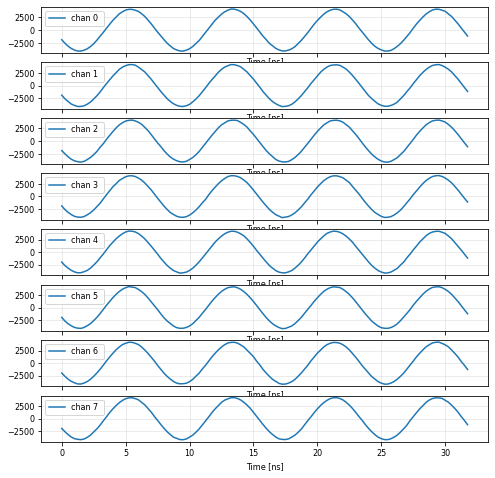

In [11]:
darray_i = np.empty((ol.n_adcs, len(ol.adc_i_bufs[0])), dtype=np.int16)
darray_q = np.empty((ol.n_adcs, len(ol.adc_q_bufs[0])), dtype=np.int16)

ol.capture_adc_iq_buf(darray_i, darray_q);
plot_adc_wfm(darray_i[:, :128], height=1)